In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import ast

In [29]:
# 1. Define the base directory generically
DATA_DIR = Path('C:/Users/iamph/OneDrive/Documents/Datasets/Kaggle_Fitness_Workout_Dataset')

# 2. Safely join the path to the file
file_path = DATA_DIR / 'program_summary_CLEAN_260728.csv'

df = pd.read_csv(file_path)

In [30]:
# 2. Safely join the path to the file
file_path = DATA_DIR / 'programs_detailed_boostcamp_kaggle_CLEAN_260728.csv'

ex = pd.read_csv(file_path)

# Adjust `level` and `goal` so we can separate the values

In [31]:
ex['level'] = ex['level'].apply(ast.literal_eval)
ex['goal'] = ex['goal'].apply(ast.literal_eval)
df['level'] = df['level'].apply(ast.literal_eval)
df['goal'] = df['goal'].apply(ast.literal_eval)

# General Statistics

## Difficulty

In [32]:
df.level.value_counts()

level
{Novice, Beginner, Intermediate, Advanced}    310
{Novice, Beginner, Intermediate}              204
{Novice, Intermediate}                        193
{Intermediate, Advanced}                      173
{Novice, Intermediate, Advanced}              158
{Intermediate}                                158
{Beginner, Novice}                             56
{Novice}                                       46
{Beginner}                                     31
{Advanced}                                     31
Name: count, dtype: int64

In [35]:
df['level'].explode().value_counts()

level
Intermediate    1196
Novice           967
Advanced         672
Beginner         601
Name: count, dtype: int64

## Goal

In [34]:
df.goal.value_counts() 

goal
{Bodybuilding}                                                                                       155
{Bodybuilding, Muscle & Sculpting}                                                                   138
{Bodybuilding, Powerbuilding, Powerlifting}                                                           96
{Bodybuilding, Powerbuilding}                                                                         88
{Bodybuilding, Muscle & Sculpting, Powerbuilding}                                                     80
                                                                                                    ... 
{Bodyweight Fitness, Powerlifting}                                                                     1
{Bodyweight Fitness, Bodybuilding, Olympic Weightlifting}                                              1
{Powerlifting, Bodybuilding, Olympic Weightlifting, Athletics, Muscle & Sculpting, Powerbuilding}      1
{Bodyweight Fitness, Muscle & Sculpting, Powerlift

In [36]:
df['goal'].explode().value_counts()

goal
Bodybuilding             1132
Powerbuilding             715
Muscle & Sculpting        691
Athletics                 483
Powerlifting              467
Bodyweight Fitness        258
Olympic Weightlifting      48
Name: count, dtype: int64

## Equipment

In [37]:
df.equipment.value_counts() 

equipment
Full Gym         929
Garage Gym       333
At Home           68
Dumbbell Only     30
Name: count, dtype: int64

## Time per workout

In [39]:
df.time_per_workout.value_counts()

time_per_workout
60     420
90     225
70     176
80     119
40     103
50      99
120     67
30      54
100     39
20      23
10      18
180      5
110      5
160      2
140      2
150      1
130      1
170      1
Name: count, dtype: int64

In [42]:
len(df.time_per_workout.value_counts())

18

<Axes: xlabel='time_per_workout'>

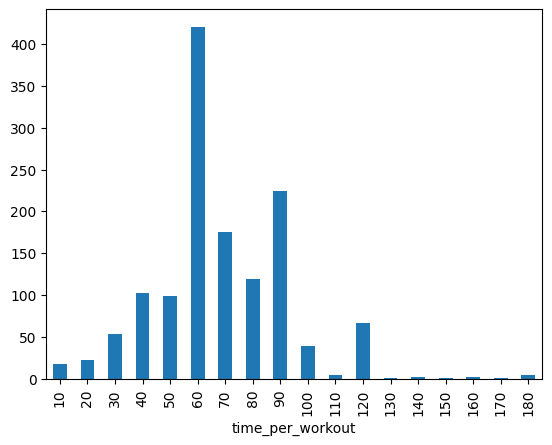

In [45]:
df.time_per_workout.value_counts().sort_index().plot.bar()

## Weeks

In [46]:
df.head()

,Unnamed: 0,title,description,level,goal,equipment,program_length_weeks,time_per_workout,total_exercises,program_length_days,average_intensity
0,0,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Novice, Beginner, Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,7,90,140,35,8.40
1,1,Rampage,Pack on muscle and gain strength through this ...,"{Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,18,70,558,108,8.51
2,2,Fitness King Powerbuild 101,To gain strength while building aesthetic musc...,"{Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,11,160,324,56,7.62
3,3,Larry's Modified Bullmastiff Powerbuilding Pro...,All credit to Alex. You can find his original ...,"{Novice, Beginner, Intermediate}","{Bodybuilding, Muscle & Sculpting, Powerbuildi...",Full Gym,9,70,342,54,7.30
4,4,Metallicdpas PPL (Reddit),"Metallicdpas’ PPL targeted towards beginners, ...","{Novice, Beginner, Intermediate}","{Athletics, Bodybuilding, Muscle & Sculpting}",Garage Gym,6,60,216,36,7.72


In [50]:
df.program_length_weeks.value_counts().sort_index()

program_length_weeks
1      73
2       9
3      49
4     215
5      60
6     149
7      20
8     215
9      35
10     57
11      4
12    372
13      8
14      5
15      7
16     54
17      1
18     27
Name: count, dtype: int64

<Axes: xlabel='program_length_weeks'>

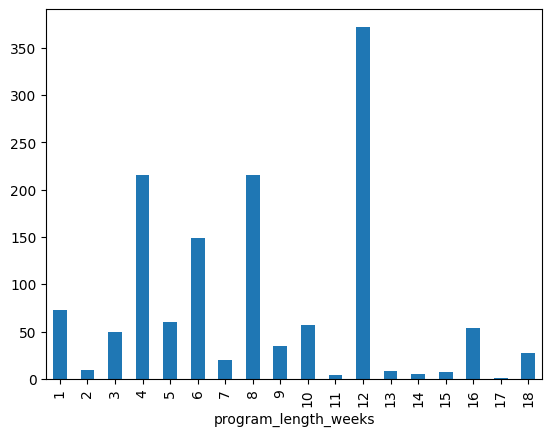

In [51]:
df.program_length_weeks.value_counts().sort_index().plot.bar()

## Program Length Days

In [56]:
min(df.program_length_days)

1

In [57]:
max(df.program_length_days)

108

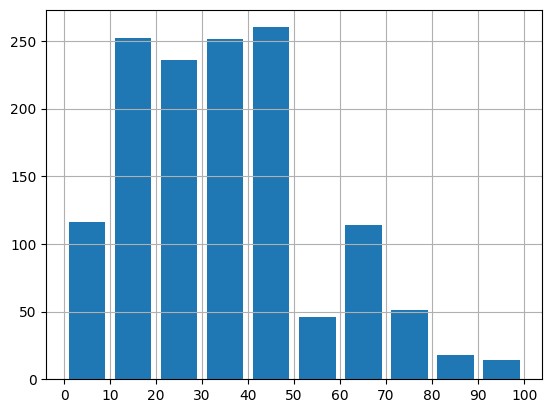

In [71]:
custom_bins = np.arange(0,110,10)
ax = df.program_length_days.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

## Intensity 

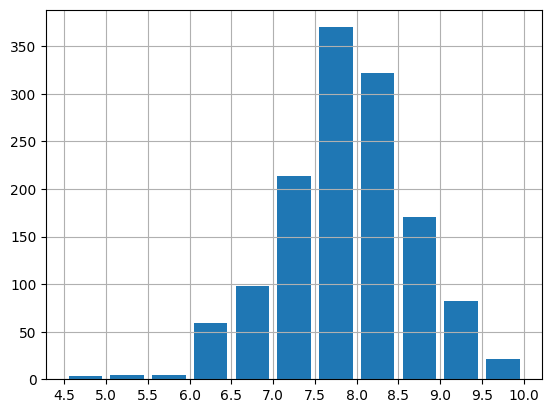

In [83]:
custom_bins = np.arange(4.5,10.5, 0.5)
ax = df.average_intensity.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

# New Variables

## Average days/week

In [84]:
df['avg_days_per_week'] = df['program_length_days'] / df['program_length_weeks']

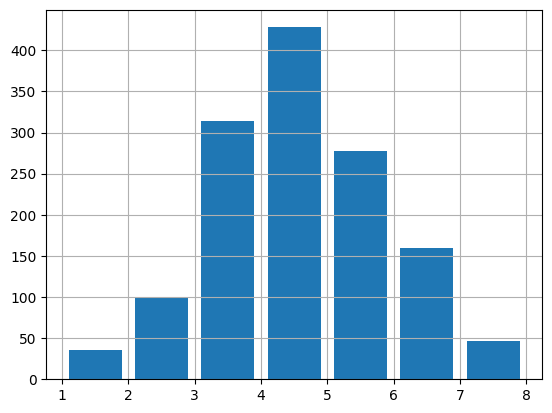

In [91]:
custom_bins = np.arange(1,9)
ax = df.avg_days_per_week.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

In [93]:
df[df.avg_days_per_week >= 7].shape

(46, 12)

In [94]:
ex.head()

,Unnamed: 0,title,description,level,goal,equipment,program_length,time_per_workout,week,day,number_of_exercises,exercise_name,sets,reps,intensity,created,last_edit
0,0,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Novice, Beginner, Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,7.0,90.0,1.0,1.0,4.0,Squat (Barbell),1.0,15.0,8.0,2025-04-06 03:06:00,2025-06-18 08:29:00
1,1,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Novice, Beginner, Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,7.0,90.0,1.0,1.0,4.0,Leg Press (45 Degrees),1.0,100.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
2,2,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Novice, Beginner, Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,7.0,90.0,1.0,1.0,4.0,Leg Extension,4.0,5.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
3,3,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Novice, Beginner, Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,7.0,90.0,1.0,1.0,4.0,Preacher Curl (Barbell),1.0,10.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00
4,4,nSuns_Rebuild by KSI,The purpose of this program is to build streng...,"{Novice, Beginner, Intermediate, Advanced}","{Bodybuilding, Powerbuilding}",Full Gym,7.0,90.0,1.0,2.0,4.0,Bent Over Row (Barbell),1.0,15.0,9.0,2025-04-06 03:06:00,2025-06-18 08:29:00


# Analysis by Difficulty

In [119]:
df.shape

(1360, 12)

In [101]:
level = 'Beginner' # Beginner, Novice, Intermediate, Advanced

In [110]:
tmp = df.level.explode() == level

In [113]:
df2 = df.loc[tmp[tmp == 1].index,:]

In [118]:
df2.shape

(601, 12)

## Goal

In [115]:
df2.goal.explode().value_counts()

goal
Bodybuilding             506
Muscle & Sculpting       345
Powerbuilding            325
Athletics                277
Powerlifting             229
Bodyweight Fitness       160
Olympic Weightlifting     25
Name: count, dtype: int64

## Equipment

In [123]:
df.equipment.value_counts()/len(df)

equipment
Full Gym         0.683088
Garage Gym       0.244853
At Home          0.050000
Dumbbell Only    0.022059
Name: count, dtype: float64

In [116]:
df2.equipment.value_counts()

equipment
Full Gym         422
Garage Gym       135
At Home           30
Dumbbell Only     14
Name: count, dtype: int64

In [122]:
df2.equipment.value_counts()/len(df2)

equipment
Full Gym         0.702163
Garage Gym       0.224626
At Home          0.049917
Dumbbell Only    0.023295
Name: count, dtype: float64

## Time Per workout

In [126]:
df.time_per_workout.value_counts().sort_index()/len(df)

time_per_workout
10     0.013235
20     0.016912
30     0.039706
40     0.075735
50     0.072794
60     0.308824
70     0.129412
80     0.087500
90     0.165441
100    0.028676
110    0.003676
120    0.049265
130    0.000735
140    0.001471
150    0.000735
160    0.001471
170    0.000735
180    0.003676
Name: count, dtype: float64

In [128]:
df2.time_per_workout.value_counts().sort_index()

time_per_workout
10       6
20      11
30      27
40      50
50      45
60     173
70      85
80      45
90     107
100     22
110      2
120     25
140      1
160      1
180      1
Name: count, dtype: int64

In [127]:
df2.time_per_workout.value_counts().sort_index()/len(df2)

time_per_workout
10     0.009983
20     0.018303
30     0.044925
40     0.083195
50     0.074875
60     0.287854
70     0.141431
80     0.074875
90     0.178037
100    0.036606
110    0.003328
120    0.041597
140    0.001664
160    0.001664
180    0.001664
Name: count, dtype: float64

<Axes: xlabel='time_per_workout'>

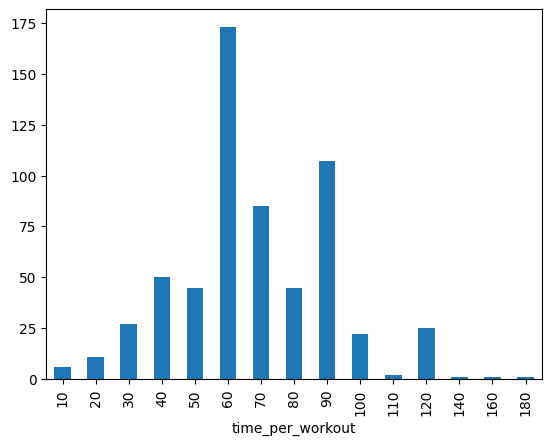

In [129]:
df2.time_per_workout.value_counts().sort_index().plot.bar()

## Weeks

In [131]:
df2.program_length_weeks.value_counts().sort_index()

program_length_weeks
1      25
2       3
3      21
4      70
5      25
6      69
7       9
8      93
9      17
10     24
11      1
12    192
13      6
14      1
15      2
16     29
18     14
Name: count, dtype: int64

<Axes: xlabel='program_length_weeks'>

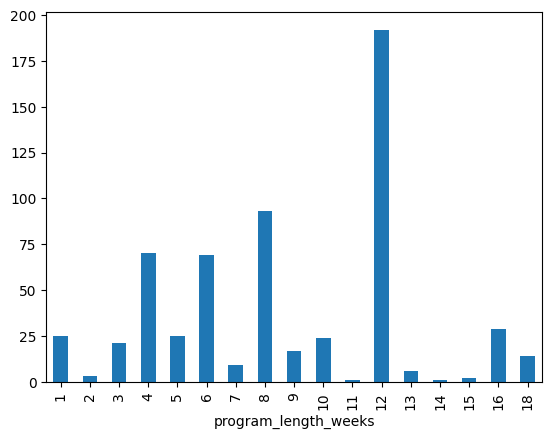

In [130]:
df2.program_length_weeks.value_counts().sort_index().plot.bar()

## Days

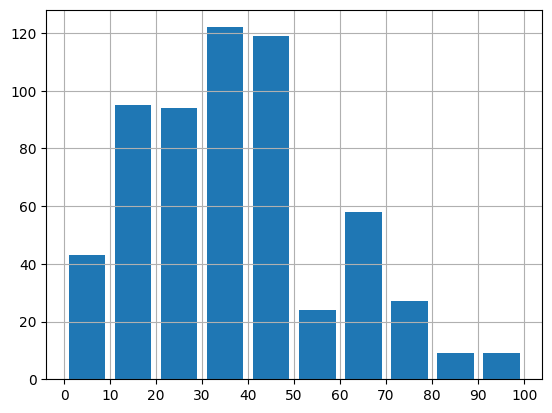

In [132]:
custom_bins = np.arange(0,110,10)
ax = df2.program_length_days.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

## Days Per week

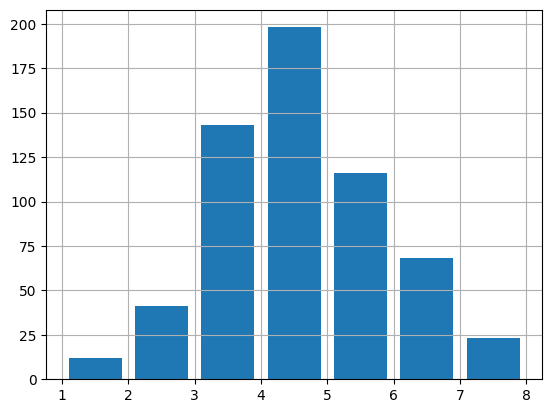

In [133]:
custom_bins = np.arange(1,9)
ax = df2.avg_days_per_week.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

## Average Intensity

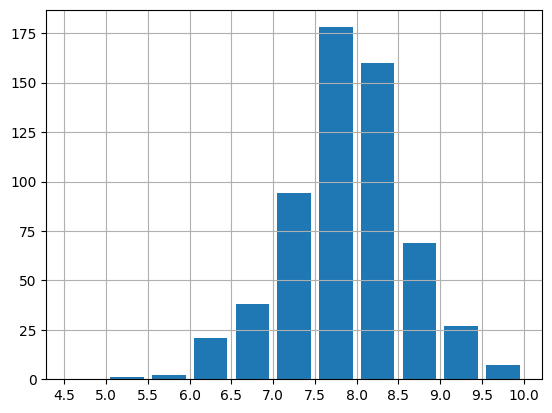

In [135]:
custom_bins = np.arange(4.5,10.5, 0.5)
ax = df2.average_intensity.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

# Analysis by Goals

In [97]:
df.goal.explode().unique() # Bodybuilding, Powerbuilding, Muscle & Sculpting, Powerlifting, Athletics, Bodyweight Fitness, Olympic Weightlifting

array(['Bodybuilding', 'Powerbuilding', 'Muscle & Sculpting',
       'Powerlifting', 'Athletics', 'Bodyweight Fitness',
       'Olympic Weightlifting'], dtype=object)

In [136]:
goal = 'Powerlifting' # Beginner, Novice, Intermediate, Advanced

In [137]:
tmp = df.goal.explode() == goal

In [138]:
df2 = df.loc[tmp[tmp == 1].index,:]

In [139]:
df2.shape

(467, 12)

## Level

In [140]:
df2.level.explode().value_counts()

level
Intermediate    431
Novice          351
Advanced        269
Beginner        229
Name: count, dtype: int64

In [141]:
df2.level.explode().value_counts()/len(df2)

level
Intermediate    0.922912
Novice          0.751606
Advanced        0.576017
Beginner        0.490364
Name: count, dtype: float64

## Equipment

In [123]:
df.equipment.value_counts()/len(df)

equipment
Full Gym         0.683088
Garage Gym       0.244853
At Home          0.050000
Dumbbell Only    0.022059
Name: count, dtype: float64

In [142]:
df2.equipment.value_counts()

equipment
Full Gym         320
Garage Gym       118
At Home           20
Dumbbell Only      9
Name: count, dtype: int64

In [143]:
df2.equipment.value_counts()/len(df2)

equipment
Full Gym         0.685225
Garage Gym       0.252677
At Home          0.042827
Dumbbell Only    0.019272
Name: count, dtype: float64

## Time Per workout

In [126]:
df.time_per_workout.value_counts().sort_index()/len(df)

time_per_workout
10     0.013235
20     0.016912
30     0.039706
40     0.075735
50     0.072794
60     0.308824
70     0.129412
80     0.087500
90     0.165441
100    0.028676
110    0.003676
120    0.049265
130    0.000735
140    0.001471
150    0.000735
160    0.001471
170    0.000735
180    0.003676
Name: count, dtype: float64

In [144]:
df2.time_per_workout.value_counts().sort_index()

time_per_workout
10       7
20       6
30      14
40      34
50      35
60     138
70      69
80      43
90      78
100     15
110      1
120     24
130      1
170      1
180      1
Name: count, dtype: int64

In [145]:
df2.time_per_workout.value_counts().sort_index()/len(df2)

time_per_workout
10     0.014989
20     0.012848
30     0.029979
40     0.072805
50     0.074946
60     0.295503
70     0.147752
80     0.092077
90     0.167024
100    0.032120
110    0.002141
120    0.051392
130    0.002141
170    0.002141
180    0.002141
Name: count, dtype: float64

<Axes: xlabel='time_per_workout'>

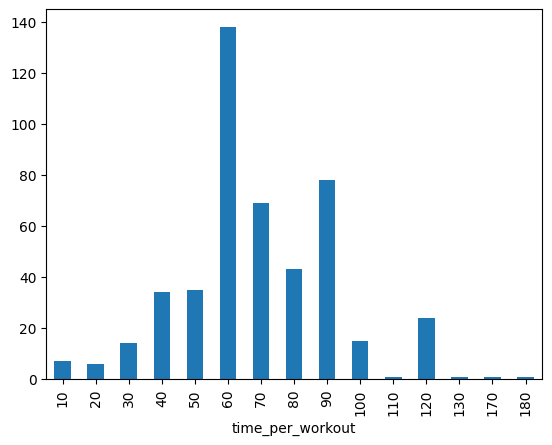

In [146]:
df2.time_per_workout.value_counts().sort_index().plot.bar()

## Weeks

In [149]:
df2.program_length_weeks.value_counts().sort_index()

program_length_weeks
1      10
2       2
3       7
4      60
5      23
6      42
7       5
8      82
9      13
10     25
11      3
12    159
13      1
15      3
16     20
17      1
18     11
Name: count, dtype: int64

<Axes: xlabel='program_length_weeks'>

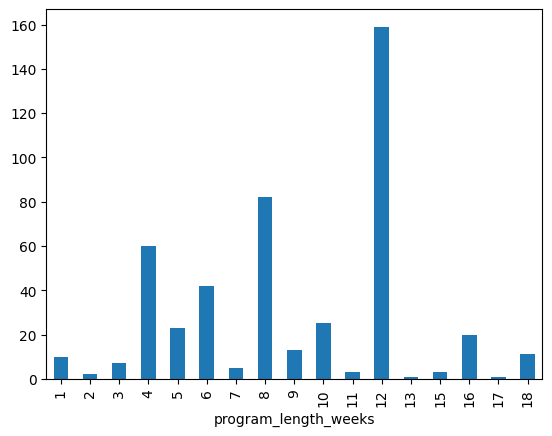

In [150]:
df2.program_length_weeks.value_counts().sort_index().plot.bar()

## Days

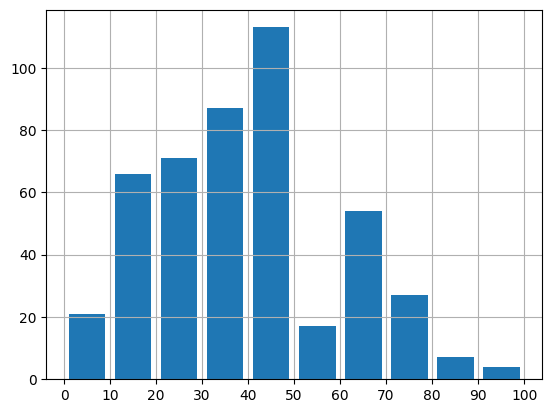

In [151]:
custom_bins = np.arange(0,110,10)
ax = df2.program_length_days.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

## Days Per week

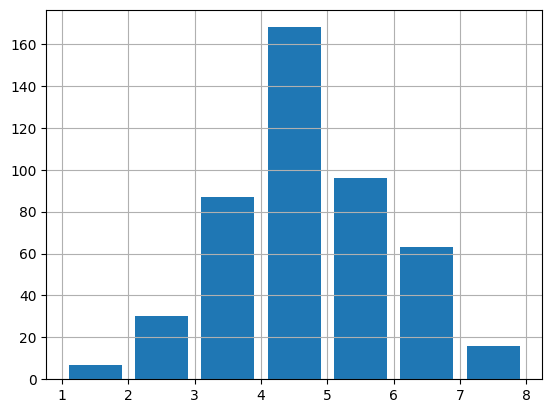

In [152]:
custom_bins = np.arange(1,9)
ax = df2.avg_days_per_week.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

## Average Intensity

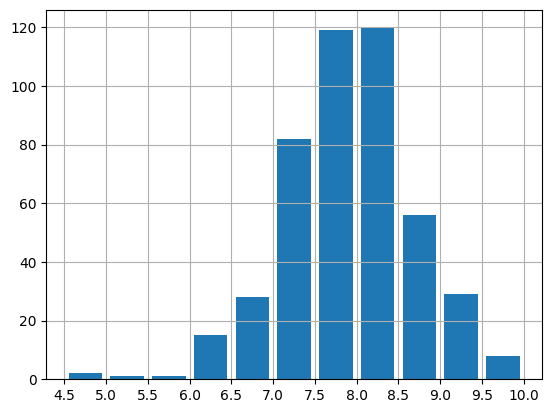

In [153]:
custom_bins = np.arange(4.5,10.5, 0.5)
ax = df2.average_intensity.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

# Analysis by Equipment

In [98]:
df.equipment.unique()

array(['Full Gym', 'Garage Gym', 'At Home', 'Dumbbell Only'], dtype=object)

In [154]:
equipment = 'Full Gym' # Beginner, Novice, Intermediate, Advanced

In [155]:
df2 = df[df.equipment == equipment]

In [156]:
df2.shape

(929, 12)

## Level

In [158]:
df2.level.explode().value_counts()

level
Intermediate    825
Novice          677
Advanced        468
Beginner        422
Name: count, dtype: int64

In [160]:
df2.level.explode().value_counts()/len(df2)

level
Intermediate    0.888052
Novice          0.728741
Advanced        0.503767
Beginner        0.454252
Name: count, dtype: float64

## Goal

In [157]:
df2.goal.explode().value_counts()

goal
Bodybuilding             782
Powerbuilding            513
Muscle & Sculpting       482
Athletics                336
Powerlifting             320
Bodyweight Fitness       171
Olympic Weightlifting     34
Name: count, dtype: int64

## Time Per workout

In [126]:
df.time_per_workout.value_counts().sort_index()/len(df)

time_per_workout
10     0.013235
20     0.016912
30     0.039706
40     0.075735
50     0.072794
60     0.308824
70     0.129412
80     0.087500
90     0.165441
100    0.028676
110    0.003676
120    0.049265
130    0.000735
140    0.001471
150    0.000735
160    0.001471
170    0.000735
180    0.003676
Name: count, dtype: float64

In [161]:
df2.time_per_workout.value_counts().sort_index()

time_per_workout
10       9
20       9
30      14
40      54
50      50
60     280
70     144
80      92
90     180
100     30
110      5
120     52
140      2
160      2
170      1
180      5
Name: count, dtype: int64

In [162]:
df2.time_per_workout.value_counts().sort_index()/len(df2)

time_per_workout
10     0.009688
20     0.009688
30     0.015070
40     0.058127
50     0.053821
60     0.301399
70     0.155005
80     0.099031
90     0.193757
100    0.032293
110    0.005382
120    0.055974
140    0.002153
160    0.002153
170    0.001076
180    0.005382
Name: count, dtype: float64

<Axes: xlabel='time_per_workout'>

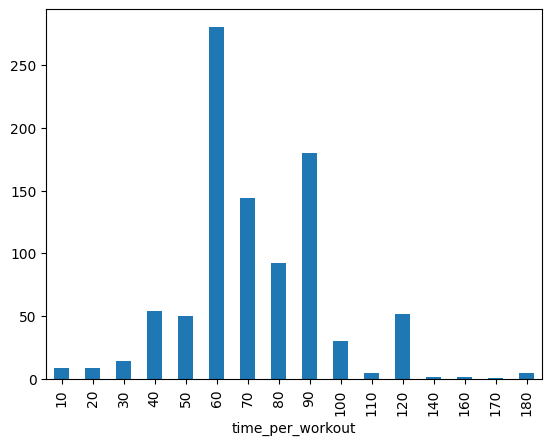

In [163]:
df2.time_per_workout.value_counts().sort_index().plot.bar()

## Weeks

In [165]:
df2.program_length_weeks.value_counts().sort_index()

program_length_weeks
1      47
2       5
3      25
4     133
5      38
6      99
7      15
8     147
9      25
10     44
11      3
12    275
13      6
14      4
15      6
16     36
17      1
18     20
Name: count, dtype: int64

<Axes: xlabel='program_length_weeks'>

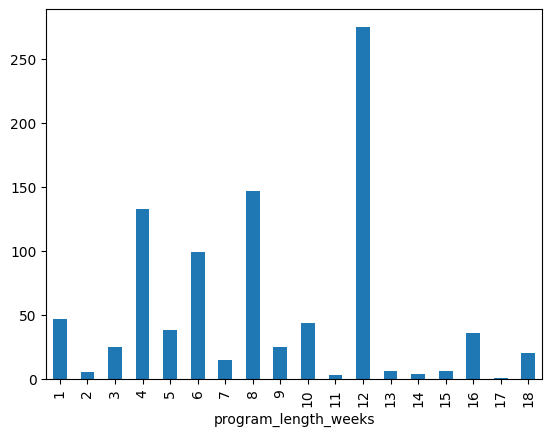

In [164]:
df2.program_length_weeks.value_counts().sort_index().plot.bar()

## Days

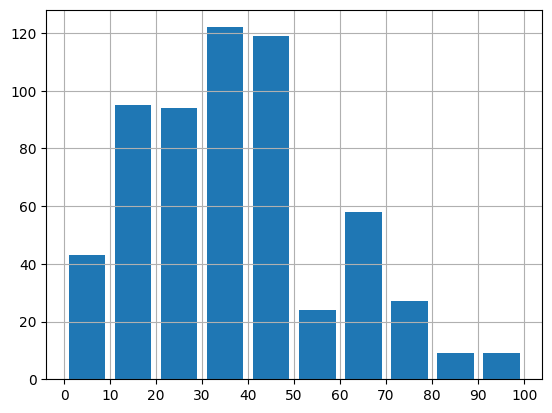

In [132]:
custom_bins = np.arange(0,110,10)
ax = df2.program_length_days.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

## Days Per week

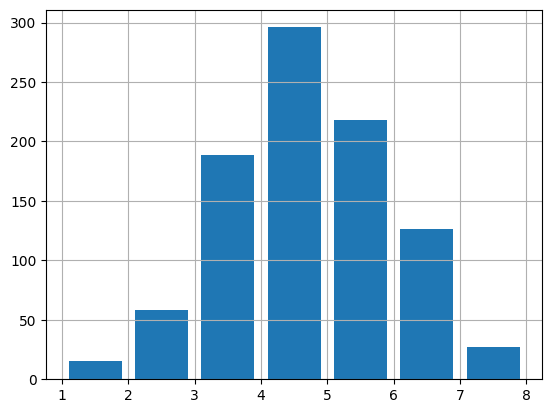

In [166]:
custom_bins = np.arange(1,9)
ax = df2.avg_days_per_week.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)

## Average Intensity

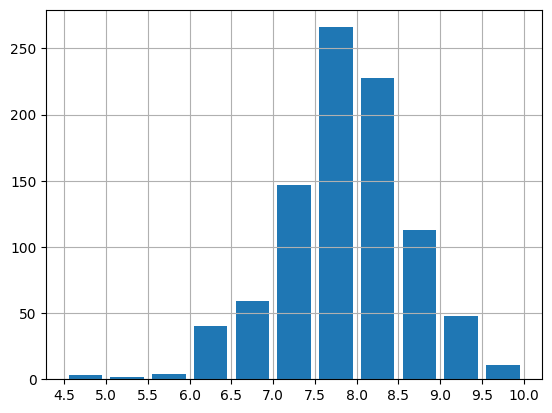

In [167]:
custom_bins = np.arange(4.5,10.5, 0.5)
ax = df2.average_intensity.hist(bins = custom_bins, rwidth = 0.8)
ax.set_xticks(custom_bins)